# Stream fitting

### Dimitra Giantsidi & Nolan Ottele 2026

This code measures the length and average width of a detected stream of a galaxy at different angles. It requires the matched-filter detection and the Segment outputs of the galaxy. It also calculates the length-to-width ratio vs. declination of observation. "Object of interest" refers to the stream throughout the code.

In [1]:
# import all necessary libraries
from pathlib import Path as path
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import re
import math
import os
import copy
import matplotlib as mpl
from scipy.optimize import curve_fit
import heapq

In [2]:
# enter the name of the galaxy, its matched-filter depth, distance and resolution, and desired number of angles
box = 'storm'
gal_num = '2'
galaxy_name = f'{box}_{gal_num}'
depth=26
distance=2000
numpix=8000
numangles=24

In [3]:
# define the necessary file paths to get the data from
sd_outputs_path = (f'../substructure_detection/sd_outputs')
segmented_path = path(f'{sd_outputs_path}/Segment/{galaxy_name}/segmented')
centers_path = path(f'{sd_outputs_path}/twod_exp_fit/{galaxy_name}/centers.txt')
mf_catalogs_path = path(f'../matched_filter/mf_data/mf_catalogs/{depth}_{distance}/{galaxy_name}/')

In [27]:
# define necessary values to be updated
area_of_interest = np.zeros((numangles, 89, 89), dtype=bool)
min_obj = 0
max_obj = 0
my_extent = [-60,60,-60,60]

In [5]:
def centers(file_name, galaxy_name):
    """ Identifies the center of the galaxy at a specific angle.
    
    Requires the 2D exponential fit algorithm to have run first and for the existence of the centers path with the centers file
    formatted exactly as defined in the 2D exponential fit algorithm. It reads the declination and azimuth of the file_name, finds
    their match in the file and their respective x- and y- coordinates.
    
    Args:
        file_name (f string):
            The name of the file of the galaxy of interest of which the first two instances of numbers 
            should be the declination and the azimuth of observation in this order (separation by period is acceptable).
        galaxy_name (f string):
            The name of the galaxy of interest.

    Returns:
        x_center (float):
            The x-coordinate of the center of the galaxy.
        y_center (float):
            The y-coordinate of the center of the galaxy.
    """
    
    x_center = 0
    y_center = 0
    numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', file_name)]
    angles = numbers[1:-1]
    d = angles[0]
    a = angles[1]
    target_message = 'center of ' f'{galaxy_name}' ' at d=' f'{d}' ' and a=' f'{a}'
    
    with open(f'{centers_path}', 'r') as file:
        for line in file:
            if target_message in line: # assumes there is only one instance of the correct message
                parts = line.strip().split(':')
                coords = parts[1].split(',')
                x_center = float(coords[0].strip())
                y_center = float(coords[1].strip())
                
    return x_center, y_center

In [247]:
# CURRENTLY WORKING ON THIS FUNCTIONS. FIX DOCUMENTATION WHEN DONE.

def area_of_interest_finder(image_data, d):
    """ Identifies and isolates the largest area of a galaxy by its Segment output.

        This function automatically updates the predefined areas_of_interest array with the identifier value of the current stream.

    Args:
        image_data (hdul.data):
            The extracted data of a Segmented galaxy (from a .fits format).

    Returns:
        image_data (hdul.data):
            The modified image data to only include the background and the area of interest
        stream_obj (float):
            The (meaningless) value assigned by Segment to the objects of interest.
        
    """
    
    # identify the largest object
    objects, counts = np.unique(image_data, return_counts=True)
    
    # ... excluding background
    not_bg_mask = objects != 0
    objects = objects[not_bg_mask]
    counts = counts[not_bg_mask]

    # identify the part of the stream that was cut off by Segment at specific angles of Storm 2 and remove everything but the stream
    if (d == 17.0 or d == 34.3 or d == 45.9 or d == 52.5 or d == 61.4 or d == 67.0 or d == 69.6 or d == 72.3 or d == 74.9 or d == 82.5 or d == 85.0 or d == 87.5):
        largest_pairs = heapq.nlargest(2, enumerate(counts), key=lambda x: x[1])
        indices = [index for index, value in largest_pairs]
        non_stream_mask = (image_data != objects[indices[0]]) & (image_data != objects[indices[1]])
        image_data[non_stream_mask] = 0
        stream_obj = (objects[indices[0]], objects[indices[1]])
    elif (d == 29.6): # at this angle, the rest of the stream was not the second largest object
        i_max = np.argmax(counts)
        non_stream_mask = (image_data != objects[i_max]) & (image_data != objects[71])
        image_data[non_stream_mask] = 0
        stream_obj = (objects[i_max], objects[71])
    else:
        i_max = np.argmax(counts)
        non_stream_mask = image_data != objects[i_max]
        image_data[non_stream_mask] = 0
        stream_obj = (objects[i_max], None)   

    # to mask the area of the matched filter
    area_of_interest[current_rotation, :, :] = (image_data == stream_obj[0]) | (image_data == stream_obj[1])

    return image_data, stream_obj

In [248]:
def radius_calc(n_of_interest, n_bins, x_center, y_center, x_of_interest, y_of_interest):
    """ Calculates the density-weighted average radius of the area of interest within each given bin.

    Args:
        n_of_interest (int):
            Number of pixels of interest.
        n_bins (int):
            Number of bins.
        x_center (float):
            The x-coordinate of the center of the galaxy.
        y_center (float):
            The y-coordinate of the center of the galaxy.
        x_of_interest (empty array):
            To be filled with the x-coordinates of the pixels of interest.
        y_of_interest (empty array):
            To be filled with the y-coordinates of the pixels of interest.

    Returns:
        avg_radii (array of floats):
            Array of length equal to n_bins containing the average radius of the object of interest within each bin.
        bin_size (float):
            The size of each bin.
    """
    
    x_delta = [n - x_center for n in x_of_interest]
    y_delta = [n - y_center for n in y_of_interest]

    theta = [0] * n_of_interest

    for i in range(len(x_delta)):
        theta[i] = np.mod(math.atan2(y_delta[i],x_delta[i]), 2*np.pi)

    bin_size = 2*np.pi/n_bins

    ang_bin = [0] * n_of_interest
    for i in range(len(theta)):
        ang_bin[i] = int(np.floor(theta[i]/bin_size))

    radii = [0] * n_of_interest
    for i in range(n_of_interest):
        radii[i] = np.sqrt(x_delta[i]**2 + y_delta[i]**2)

    avg_radii = [0] * n_bins

    for j in range(n_bins):
        radii_sum = 0
        radii_counter = 0
        for i in range(len(ang_bin)):
            if ang_bin[i] == j:
                radii_sum = radii_sum + radii[i]
                radii_counter = radii_counter + 1
        if radii_counter == 0:
            radii_average = 0
        else:
            radii_average = radii_sum / radii_counter
        avg_radii[j] = radii_average
    avg_radii = np.array(avg_radii)

    return avg_radii, bin_size

In [249]:
current_rotation = 0

# isolate the area of interest, split it into angular bins and calculate its density-weighted average radius within each bin
for file in sorted(segmented_path.iterdir()):
    if file.is_file():

        numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', f'{file.name}')]
        angles = numbers[1:-1]
        d = angles[0]
        a = angles[1]

        # load the segmented fits file
        hdul = fits.open(f'{segmented_path}/{file.name}')
        image_data = hdul[3].data # 3 is the index of isolated objects

        # access centers calculated by the 2D exponential fit algorithm
        x_center, y_center = centers(f'{file.name}', galaxy_name)

        # plot the bins (only for visual aid purposes)
        n_bins = 32
        
        # find area of interest
        image_data, stream_obj = area_of_interest_finder(image_data, d)

        x_of_interest = []
        y_of_interest = []

        # find data of interest (non-background and of largest object)
        for r_idx, row in enumerate(image_data):
            for c_idx, val in enumerate(row):
                if ((val == stream_obj[0]) or (val == stream_obj[1])):
                    # scale the data size (89x89) to the plot size (120x120) 
                    scaled_r = -60 + (r_idx * (120 / 89)) #- 120/178
                    scaled_c = -60 + (c_idx * (120 / 89)) #- 120/178
                    x_of_interest.append(scaled_c) # try switching columns and rows
                    y_of_interest.append(scaled_r)

        # number of pixels of interest
        n_of_interest = len(x_of_interest)

        # calculate the average readius of each bin
        avg_radii = radius_calc(n_of_interest, n_bins, x_center, y_center, x_of_interest, y_of_interest)
        
        current_rotation = current_rotation + 1

In [250]:
def find_large_outliers(data, multiplier=1.5):
    """ Finds only large, extreme upper outliers while ignoring small values.

    Args:
        data (array of numbers):
            The desired data to be checked for large outliers.

    Returns:
        outlier_values (number or array of numbers):
            The numbers identified as large outliers.
    """
    data = np.array(data)
    
    # Calculate upper quartile parameters
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    
    # Establish a high upper fence
    upper_bound = q3 + (multiplier * iqr)
    
    # Extract only values exceeding this high threshold
    outlier_indices = np.where(data > upper_bound)
    outlier_values = data[outlier_indices]
    
    return outlier_values

In [251]:
def ray_cells_in_grid(x0, y0, dx, dy, width, height):
    """Amanatides-Woo traversal algorithm. Copied from the internet. Calculates the grid pixels a line goes through.
    Basic idea is to calculate parametrically which edge of the box a line is approaching at any given time.

    Args:
        x0 (int):
            Starting x value in grid coordinates
        y0 (int):
            Starting y value in grid coordinates
        dx (int):
            Change in x with respect to time. Really just numerator of slope.
        dy (int): 
            Change in y with respect to time. Really just denominator of slope.
        width (int):
            X size of the grid.
        height (int):
            Y size of the grid

    Returns:
        cells (2D array of ints):
            A list of cells the line goes through, including the first cell it starts in.     
    """
    if dx == 0 and dy == 0:
        raise ValueError("direction vector (dx, dy) cannot be (0, 0)")
 
    i, j = math.floor(x0), math.floor(y0)
    if not (0 <= i < width and 0 <= j < height):
        return []
    cells = [(x0,y0),(i, j)]
 
    step_i = 1 if dx > 0 else (-1 if dx < 0 else 0)
    step_j = 1 if dy > 0 else (-1 if dy < 0 else 0)
 
    # tMaxX/tMaxY: parametric distance to the next vertical/horizontal
    # grid line. tDeltaX/tDeltaY: how much that increases per cell.
    if dx != 0:
        next_x = i + (1 if dx > 0 else 0)
        tMaxX = (next_x - x0) / dx
        tDeltaX = abs(1.0 / dx)
    else:
        tMaxX = math.inf
        tDeltaX = math.inf
 
    if dy != 0:
        next_y = j + (1 if dy > 0 else 0)
        tMaxY = (next_y - y0) / dy
        tDeltaY = abs(1.0 / dy)
    else:
        tMaxY = math.inf
        tDeltaY = math.inf
 
    while True:
        if tMaxX < tMaxY:
            tMaxX += tDeltaX
            i += step_i
        elif tMaxY < tMaxX:
            tMaxY += tDeltaY
            j += step_j
        else:
            tMaxX += tDeltaX
            tMaxY += tDeltaY
            i += step_i
            j += step_j
 
        if not (0 <= i < width and 0 <= j < height):
            break
        cells.append((i, j))
        if len(cells)>=11:
            break
 
    return cells

In [252]:
def length_calc(n_bins, x_center, y_center, x_ang, y_ang):
    """ Calculates the total length of the stream.

    Args:
        n_bins (int):
            Number of bins.
        x_center (float):
            The x-coordinate of the center of the galaxy.
        y_center (float):
            The y-coordinate of the center of the galaxy.
        x_ang (array of floats):
            The x-coordinates of the angular midpoints of the bins at the average radius.
        y_ang (array of floats):
            The y-coordinates of the angular midpoints of the bins at the average radius.

    Returns:
        total_dist (float):
            The total calculated length of the stream.
    """

    total_dist = 0
    
    for i in range(n_bins):
        
        # calculate the separation between a pair of points
        p1 = i
        p2 = np.mod(i+1, n_bins) # enables looping from final bin to first bin
        
        x_sep = x_ang[p1]-x_ang[p2]
        y_sep = y_ang[p1]-y_ang[p2]

        dist = 0
        
        if (x_ang[p1] != x_center or y_ang[p1] != y_center) and (x_ang[p2] != x_center or y_ang[p2] != y_center): 
            dist = np.sqrt(x_sep**2 + y_sep**2) # distance for this specific pair
            total_dist = total_dist + dist  # total accumulated distance

            plt.plot([x_ang[p1], x_ang[p2]], [y_ang[p1], y_ang[p2]], color = '#72BCD4', alpha=0.5) # line from point 1 to point 2

    return total_dist

In [253]:
def width_calc(image_data, n_bins, x_ang, y_ang):
    """ Calculates the width of bins of the stream.

    Args:
        image_data (hdul.data):
            The extracted data of a matched-filtered galaxy (from a .fits format).
        n_bins (int):
            Number of bins.
        x_ang (array of floats):
            The x-coordinates of the angular midpoints of the bins at the average radius.
        y_ang (array of floats):
            The y-coordinates of the angular midpoints of the bins at the average radius.

    Returns:
        stream_width_counter (int):
            The number of widths calculated.
        stream_width_total (float):
            The sum of the widths calculated.
    """

    stream_width = 0
    stream_width_counter = 0
    stream_width_total = 0

    for i in range(n_bins):
    
        p1 = i
        p2 = np.mod(i+1, n_bins) # enables looping from final bin to first bin
    
        x_mid = (x_ang[p1]+x_ang[p2])/2
        y_mid = (y_ang[p1]+y_ang[p2])/2
        #plt.scatter(x_mid, y_mid, color = 'green', s=20) # plots midpoints between any two given points
    
        x_mid_as_grid = round((60+x_mid)*89/120) # converts midpoints into grid coordinates
        y_mid_as_grid = 89-round((60+y_mid)*89/120)
    
        # calculate the separation between a pair of points
        x_sep = x_ang[p1]-x_ang[p2]
        y_sep = y_ang[p1]-y_ang[p2]

        dist = 0
        if (x_ang[p1] != x_center or y_ang[p1] != y_center) and (x_ang[p2] != x_center or y_ang[p2] != y_center): 
            dist = np.sqrt(x_sep**2 + y_sep**2) # distance for this specific pair
    
        if x_sep == 0 and y_sep == 0: 
            print(f"{i}. Invalid. No separation.") # prevents crashing in case of non-existing average radius/radii
            
        else:
            cells_1 = ray_cells_in_grid(x_mid_as_grid, y_mid_as_grid, y_sep, x_sep, 89, 89) # lists all cells in line in one direction from muidpoing
            cells_2 = ray_cells_in_grid(x_mid_as_grid, y_mid_as_grid, -y_sep, -x_sep, 89, 89) # lists all cells in opposite direction
    
            emtpy_limit = 5 # limit for consecutive empty encounters. WE STRONGLY ADVISE TO ADJUST FOR EACH GALAXY
            far_limit = 11 # limit for parts of the stream being too close to each other
            
            # identify stopping points due to empty encounters in both directions
            limit_1 = 0
            for n in range(far_limit):
                if (image_data[cells_1[n][1]][cells_1[n][0]]) == 0:
                    break_counter = 0
                    for m in range(emtpy_limit):
                        if n+m <= len(cells_1):
                            if (image_data[cells_1[n+m-1][1]][cells_1[n+m-1][0]]) == 0:
                                break_counter = break_counter + 1
                            else:
                                break
                        else:
                            break
                    limit_1 = n
                    if break_counter == emtpy_limit:
                        break
                limit_1 = n
    
            limit_2 = 0
            for n in range(far_limit):
                if (image_data[cells_2[n][1]][cells_2[n][0]]) == 0:
                    break_counter = 0
                    for m in range(emtpy_limit):
                        if n+m <= len(cells_2):
                            if (image_data[cells_2[n+m-1][1]][cells_2[n+m-1][0]]) == 0:
                                break_counter = break_counter + 1
                            else:
                                break
                        else:
                            break
                    limit_2 = n
                    if break_counter == emtpy_limit:
                        break
                limit_2 = n
    
            # apply stopping points in both directions
            cells_1_culled = [[x, y] for x, y in cells_1[:limit_1] if not ((image_data[y][x]) == 0)]
            cells_2_culled = [[x, y] for x, y in cells_2[:limit_2] if not ((image_data[y][x]) == 0)]
    
            if len(cells_1_culled)!=0 and len(cells_2_culled)!=0: # case where the area extends in both directions
                
                cell_first = cells_1_culled[-1] # selects the farthest cell from the culled population
                cell_last = cells_2_culled[-1]
    
                cell_first_x_coord = (-60 + (cell_first[0] * (120 / 89))) + 60/89  # coordintes of centers of endpoint cells in image coordinates
                cell_last_x_coord = (-60 + (cell_last[0] * (120 / 89))) +60/89
    
                cell_first_y_coord = (-60 + (-(cell_first[1]-89) * (120 / 89))) -60/89 
                cell_last_y_coord = (-60 + (-(cell_last[1]-89) * (120 / 89))) -60/89 
    
                plt.plot([cell_first_x_coord, cell_last_x_coord], [cell_first_y_coord, cell_last_y_coord], color = 'teal') # plots line connecting endpoints
                stream_width = np.sqrt((cell_first_x_coord - cell_last_x_coord)**2 + (cell_first_y_coord - cell_last_y_coord)**2)
                
                print(f"{i} Width: {stream_width}. Distance: {dist}")
    
                stream_width_counter = stream_width_counter + 1
                stream_width_total = stream_width_total + stream_width
    
            elif len(cells_1_culled)==0 and len(cells_2_culled)!=0: # case where the area does not extend in one direction
    
                cell_first = cells_2_culled[0] # selects the farthest cell from the culled population
                cell_last = cells_2_culled[-1]
    
                cell_first_x_coord = (-60 + (cell_first[0] * (120 / 89))) + 60/89  # coordinates of centers of endpoint cells in image coordinates
                cell_last_x_coord = (-60 + (cell_last[0] * (120 / 89))) +60/89
    
                cell_first_y_coord = (-60 + (-(cell_first[1]-89) * (120 / 89))) -60/89 
                cell_last_y_coord = (-60 + (-(cell_last[1]-89) * (120 / 89))) -60/89 
    
                plt.plot([cell_first_x_coord, cell_last_x_coord], [cell_first_y_coord, cell_last_y_coord], color = 'teal') # plots line connecting endpoints
                stream_width = np.sqrt((cell_first_x_coord - cell_last_x_coord)**2 + (cell_first_y_coord - cell_last_y_coord)**2)
                
                print(f"{i} Width: {stream_width}. Distance: {dist}")
    
                stream_width_counter = stream_width_counter + 1
                stream_width_total = stream_width_total + stream_width
    
            elif len(cells_1_culled)!=0 and len(cells_2_culled)==0: # case where the area does not extend in the other direction
    
                cell_first = cells_1_culled[0] # selects the farthest cell from the culled population
                cell_last = cells_1_culled[-1]
    
                cell_first_x_coord = (-60 + (cell_first[0] * (120 / 89))) + 60/89  # coordintes of centers of endpoint cells in image coordinates
                cell_last_x_coord = (-60 + (cell_last[0] * (120 / 89))) +60/89
    
                cell_first_y_coord = (-60 + (-(cell_first[1]-89) * (120 / 89))) -60/89 
                cell_last_y_coord = (-60 + (-(cell_last[1]-89) * (120 / 89))) -60/89 
    
                plt.plot([cell_first_x_coord, cell_last_x_coord], [cell_first_y_coord, cell_last_y_coord], color = 'teal') # plots line connecting endpoints
                stream_width = np.sqrt((cell_first_x_coord - cell_last_x_coord)**2 + (cell_first_y_coord - cell_last_y_coord)**2)
                
                print(f"{i} Width: {stream_width}. Distance: {dist}")
    
                stream_width_counter = stream_width_counter + 1
                stream_width_total = stream_width_total + stream_width
                
            else: # case where the area does not extend in either direction
                 print(f"{i}. Invalid. No width.")

    return stream_width_counter, stream_width_total

0 Width: 8.201477568941415. Distance: 3.6370096268823695
1 Width: 10.530673720323577. Distance: 3.7137482930967685
2 Width: 5.55924354015865. Distance: 4.109762494930618
3 Width: 4.263745159777586. Distance: 4.557901692849649
4 Width: 3.8136096063993516. Distance: 4.321440585582883
5 Width: 8.63342593811171. Distance: 4.861176678622297
6 Width: 7.861957611027364. Distance: 5.096901235645786
7 Width: 10.268458120265944. Distance: 5.671886524444848
8. Invalid. No width.
9 Width: 12.430846459271308. Distance: 5.895756789895939
10 Width: 12.430846459271308. Distance: 5.329543034418121
11 Width: 13.279358833882387. Distance: 5.703358735280931
12 Width: 15.781617857150051. Distance: 7.45545144517299
13 Width: 12.430846459271308. Distance: 8.096859304020716
14 Width: 9.722834900127607. Distance: 9.38805578616848
15 Width: 7.86195761102737. Distance: 6.985817767629571
16. Invalid. No width.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No sepa

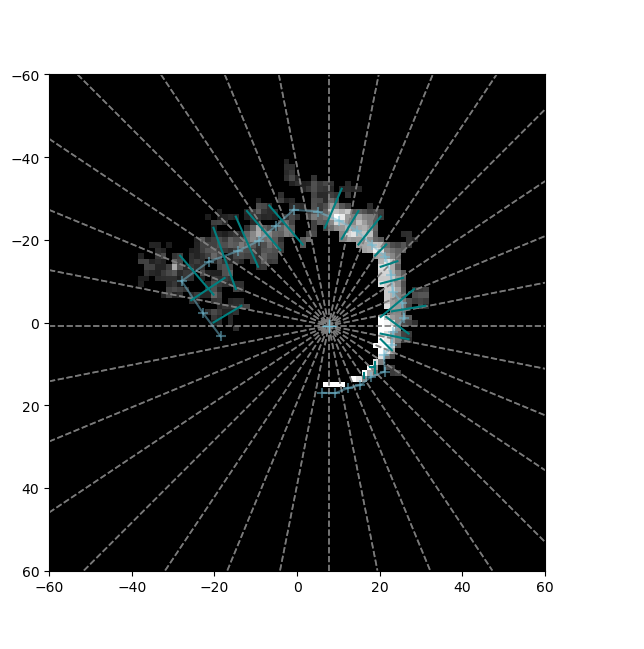

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No width.
4. Invalid. No width.
5. Invalid. No separation.
6. Invalid. No width.
7 Width: 0.0. Distance: 3.003062820177153
8 Width: 3.8136096063993565. Distance: 5.041486671060309
9 Width: 4.861417450063807. Distance: 3.576368978055487
10 Width: 1.9068048031996807. Distance: 3.5180427284193927
11 Width: 1.3483146067415674. Distance: 2.8609549711123097
12 Width: 3.0149231157300536. Distance: 2.9259406707658666
13 Width: 4.263745159777595. Distance: 4.902994988550245
14 Width: 6.741573033707863. Distance: 4.828033359322691
15 Width: 10.870459885346357. Distance: 4.294389998673172
16 Width: 8.201477568941423. Distance: 4.373060596394725
17 Width: 6.875082490237462. Distance: 5.664372635133139
18 Width: 10.268458120265946. Distance: 5.234909181884128
19 Width: 9.722834900127603. Distance: 5.426173552660468
20 Width: 9.534024015998396. Distance: 5.67772382506779
21 Width: 10.530673720323575. Distanc

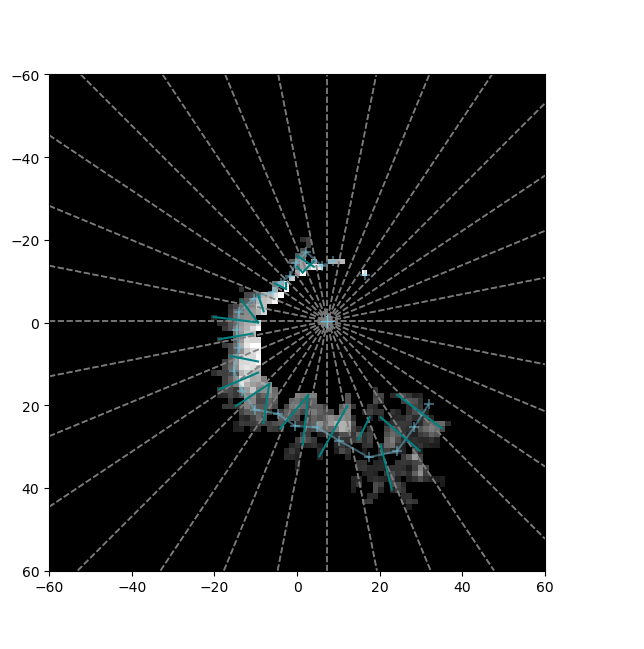

0 Width: 11.598640809495677. Distance: 5.3949813761232885
1 Width: 10.870459885346358. Distance: 4.925641675512652
2 Width: 13.483146067415728. Distance: 4.779925357117057
3 Width: 12.20950805142124. Distance: 5.831481527706098
4 Width: 15.373151799089495. Distance: 7.976764619814213
5 Width: 16.291747380127507. Distance: 6.426438578386423
6 Width: 12.20950805142124. Distance: 6.4904525074360295
7 Width: 9.81587850240069. Distance: 6.604032687758433
8. Invalid. No width.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No separation.
15. Invalid. No width.
16. Invalid. No width.
17 Width: 0.0. Distance: 3.4625665359128464
18 Width: 3.01492311573006. Distance: 3.930994818608345
19 Width: 10.870459885346358. Distance: 3.975389829817922
20 Width: 5.720414409599033. Distance: 3.9374815993144345
21 Width: 5.55924354015865. Distance: 4.293588683406337
22 Width: 7.260896369170119. Distance: 

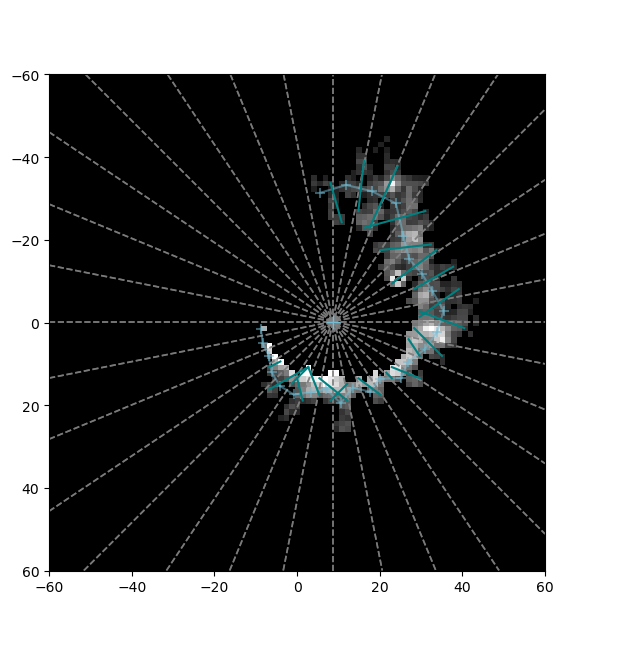

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No width.
6 Width: 1.3483146067415746. Distance: 3.679414535907049
7 Width: 4.2637451597775975. Distance: 4.240088904531234
8 Width: 1.9068048031996807. Distance: 4.785049995202907
9 Width: 8.201477568941423. Distance: 5.338049834144932
10 Width: 13.550394095893335. Distance: 5.909171263988631
11 Width: 15.373151799089502. Distance: 5.5848786094307625
12 Width: 12.430846459271313. Distance: 5.619790561589405
13 Width: 8.201477568941423. Distance: 5.76907039021204
14 Width: 15.074615578650269. Distance: 5.719448338591363
15 Width: 12.059692462920214. Distance: 6.852710930496195
16 Width: 12.430846459271306. Distance: 7.502078448121653
17 Width: 14.58425235019142. Distance: 7.625713284815433
18 Width: 10.53067372032358. Distance: 6.223745030171176
19 Width: 3.8136096063993565. Distance: 6.22904587653214
20. Invalid. No width.
21. Invalid. No s

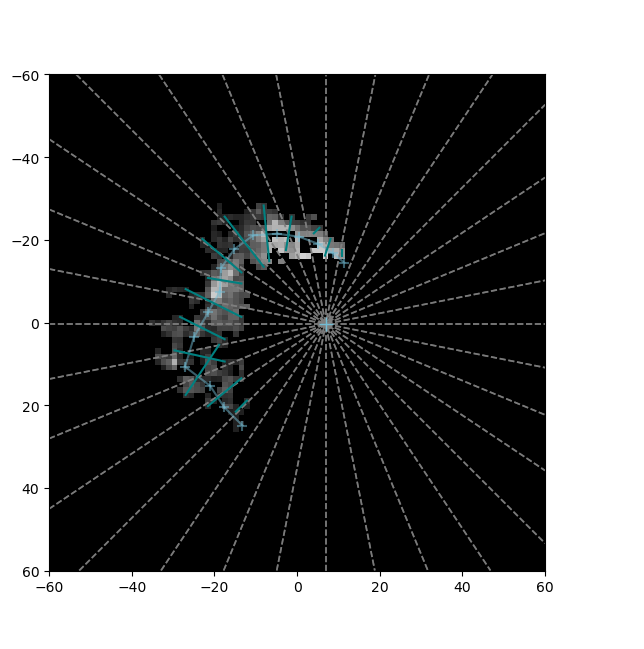

0 Width: 12.43084645927131. Distance: 7.059880606305265
1. Invalid. No width.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12 Width: 7.2608963691701165. Distance: 0
13 Width: 3.0149231157300473. Distance: 6.62828609352139
14 Width: 7.861957611027375. Distance: 4.621545627204017
15 Width: 1.3483146067415746. Distance: 5.444732697405297
16 Width: 6.7415730337078665. Distance: 3.943273178532658
17 Width: 3.01492311573006. Distance: 3.644306823993166
18 Width: 1.3483146067415666. Distance: 3.9333929390589617
19 Width: 3.813609606399356. Distance: 3.8395838896073182
20 Width: 5.5592435401586515. Distance: 4.744047298240267
21 Width: 8.201477568941414. Distance: 4.4596889673697655
22 Width: 0.0. Distance: 3.905008530714503
23 Width: 4.861417450063806. Distance: 4.62460

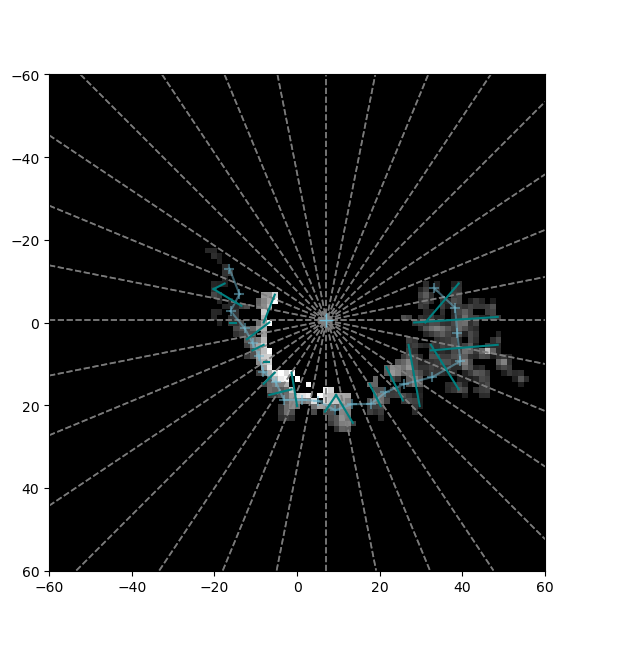

0 Width: 5.55924354015865. Distance: 4.132450756538742
1 Width: 4.8614174500638025. Distance: 4.114213311366321
2 Width: 5.55924354015865. Distance: 4.77163704268798
3 Width: 12.430846459271313. Distance: 4.5615043920770155
4 Width: 9.722834900127609. Distance: 4.6284738769797045
5 Width: 9.72283490012761. Distance: 4.703130171289573
6 Width: 8.527490319555177. Distance: 5.041296044941741
7 Width: 12.209508051421237. Distance: 4.300452671588599
8 Width: 12.209508051421237. Distance: 4.681183397701531
9 Width: 12.209508051421237. Distance: 5.20809901035047
10 Width: 14.521792738340235. Distance: 5.262480435443018
11 Width: 8.52749031955518. Distance: 6.5456825305182775
12 Width: 10.530673720323575. Distance: 6.306548402793886
13 Width: 9.53402401599839. Distance: 6.477837193045739
14 Width: 0.0. Distance: 5.805450197669663
15. Invalid. No width.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No width.
21 Width

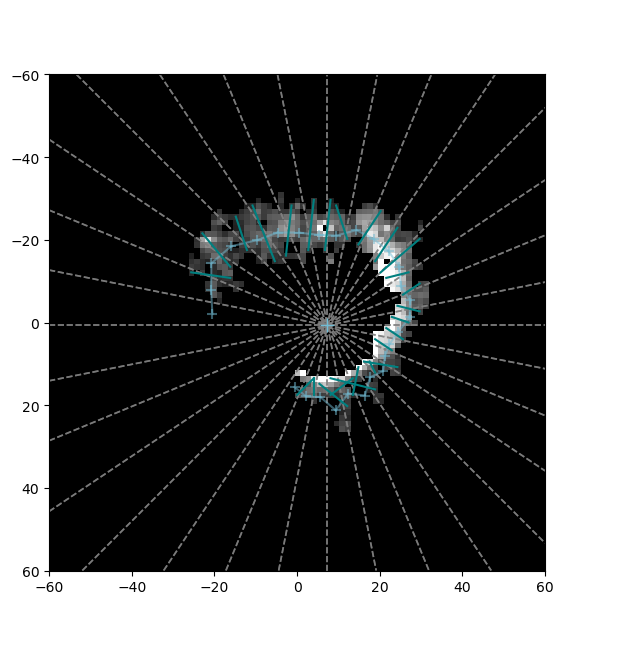

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No width.
11 Width: 4.861417450063801. Distance: 3.879619069142048
12 Width: 4.263745159777589. Distance: 4.756351512268976
13 Width: 4.861417450063811. Distance: 7.048199231781438
14 Width: 4.263745159777589. Distance: 5.334825077249261
15 Width: 10.870459885346364. Distance: 5.266350153994021
16 Width: 6.741573033707868. Distance: 5.558713202001448
17 Width: 10.26845812026594. Distance: 4.885277740143721
18 Width: 13.48314606741574. Distance: 4.903510380531371
19 Width: 13.483146067415726. Distance: 4.959856021856737
20 Width: 13.279358833882394. Distance: 4.959881492771727
21 Width: 11.440828819198071. Distance: 5.509605754834168
22 Width: 17.528089887640444. Distance: 5.463088645773101
23 Width: 8.633425

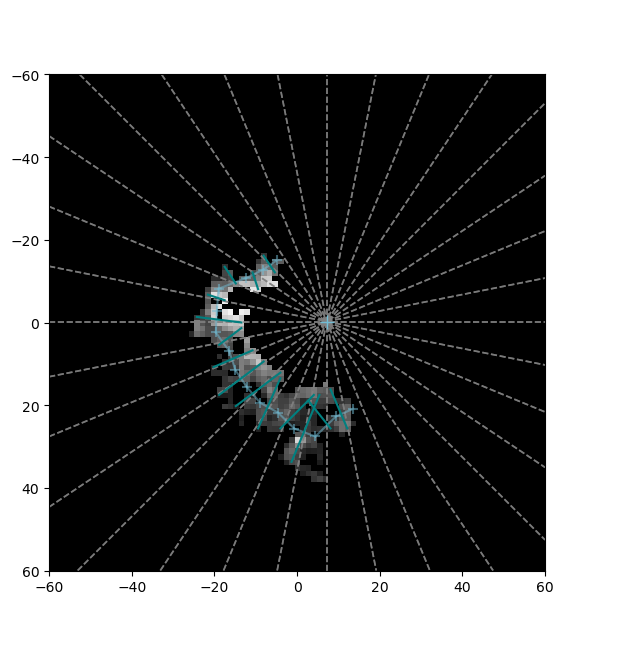

0 Width: 14.892621596207535. Distance: 5.981693662478612
1 Width: 10.870459885346357. Distance: 7.278827878216251
2 Width: 13.279358833882391. Distance: 5.55970079622872
3 Width: 9.04476934719017. Distance: 5.020441507226737
4 Width: 8.08988764044944. Distance: 5.692650870479414
5. Invalid. No width.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No width.
13 Width: 4.263745159777589. Distance: 5.756163242013046
14 Width: 1.9068048031996807. Distance: 5.331722814446178
15 Width: 1.9068048031996807. Distance: 4.97228457301466
16 Width: 3.8136096063993614. Distance: 4.283394157982315
17 Width: 6.87508249023746. Distance: 4.584560512452674
18 Width: 6.741573033707858. Distance: 5.890945825202962
19 Width: 4.861417450063811. Distance: 3.3781540661339373
20 Width: 9.722834900127609. Distance: 3.5977163103225323
21 Width: 6.875082490237463. Distance: 3.77552204450

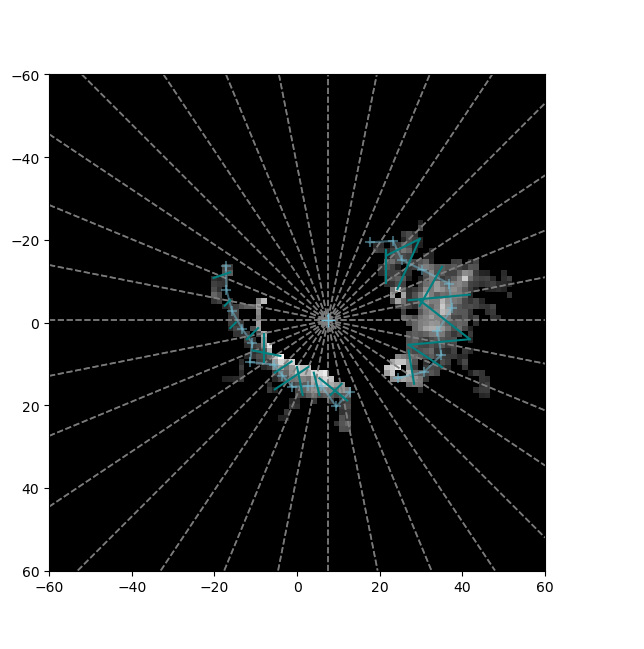

0 Width: 1.3483146067415674. Distance: 3.493163709486909
1 Width: 3.0149231157300567. Distance: 3.3840654463944104
2 Width: 9.815878502400702. Distance: 5.3232006012422675
3 Width: 5.559243540158641. Distance: 4.635571551131182
4 Width: 6.875082490237465. Distance: 4.539784064134458
5 Width: 4.861417450063802. Distance: 3.631242920788641
6 Width: 6.741573033707868. Distance: 4.082148789121696
7 Width: 12.43084645927131. Distance: 3.8623037237166176
8 Width: 10.870459885346364. Distance: 4.0421311090789
9 Width: 10.870459885346364. Distance: 4.15417451959835
10 Width: 9.53402401599839. Distance: 4.709890703427541
11 Width: 8.527490319555175. Distance: 5.597052366000262
12 Width: 13.279358833882391. Distance: 6.367457696375737
13 Width: 11.59864080949567. Distance: 7.539652418755304
14 Width: 16.40295513788284. Distance: 6.576617629345709
15 Width: 8.201477568941419. Distance: 6.912233304132665
16 Width: 0.0. Distance: 7.4612614849729475
17. Invalid. No width.
18. Invalid. No separation.

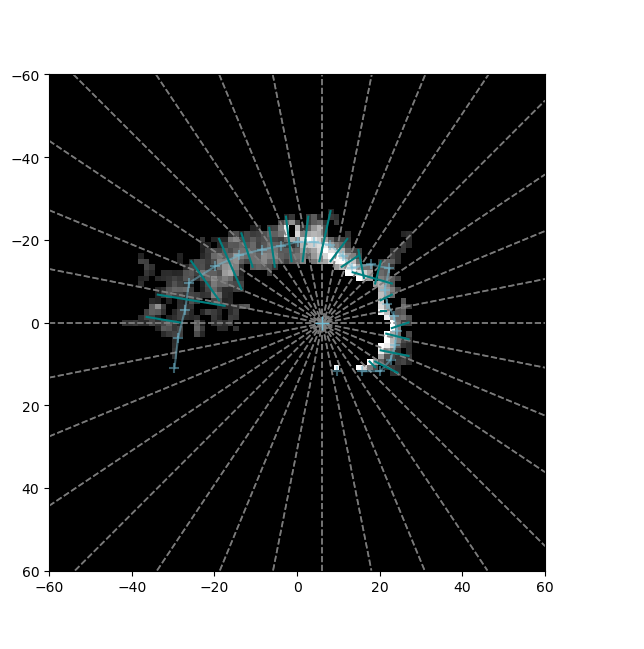

0. Invalid. No width.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No width.
15 Width: 4.263745159777589. Distance: 4.139046293300739
16 Width: 1.9068048031996758. Distance: 4.3820948027721105
17 Width: 3.0149231157300473. Distance: 5.668181129656049
18 Width: 10.53067372032358. Distance: 4.989645010661647
19 Width: 1.3483146067415674. Distance: 5.861190780009559
20 Width: 4.861417450063811. Distance: 4.433900627004824
21 Width: 6.875082490237463. Distance: 4.5463691964953545
22 Width: 1.906804803199686. Distance: 4.604260655606816
23 Width: 3.0149231157300536. Distance: 3.4890072283352045
24. Invalid. No width.
25. Invalid. No separation.
26. Invalid. No width.
27 Wid

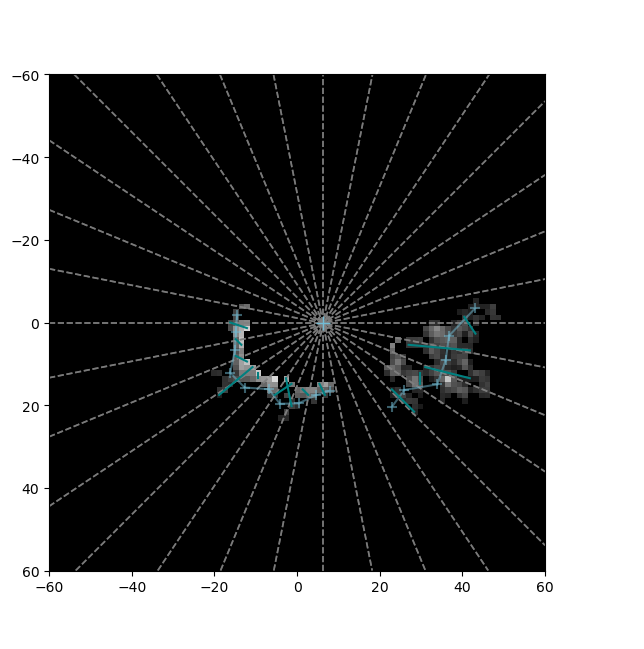

0 Width: 10.870459885346355. Distance: 4.623281927289357
1 Width: 11.520005049866327. Distance: 4.676554106254083
2 Width: 11.598640809495674. Distance: 4.898493218477863
3 Width: 13.881748504701573. Distance: 4.322399530722306
4 Width: 10.530673720323586. Distance: 4.317983547690292
5 Width: 12.059692462920214. Distance: 4.311883379465853
6 Width: 9.534024015998398. Distance: 4.358843657854932
7 Width: 10.870459885346358. Distance: 4.160148217317244
8 Width: 7.861957611027375. Distance: 4.261294298757499
9 Width: 8.20147756894142. Distance: 4.108220011437547
10 Width: 7.8619576110273695. Distance: 4.158906959623556
11 Width: 1.3483146067415666. Distance: 4.165154954769765
12. Invalid. No width.
13. Invalid. No separation.
14. Invalid. No separation.
15. Invalid. No separation.
16. Invalid. No width.
17 Width: 0.0. Distance: 3.351201812976107
18 Width: 1.3483146067415746. Distance: 3.2873151598626547
19 Width: 3.8136096063993614. Distance: 3.2835026085455197
20 Width: 3.813609606399346

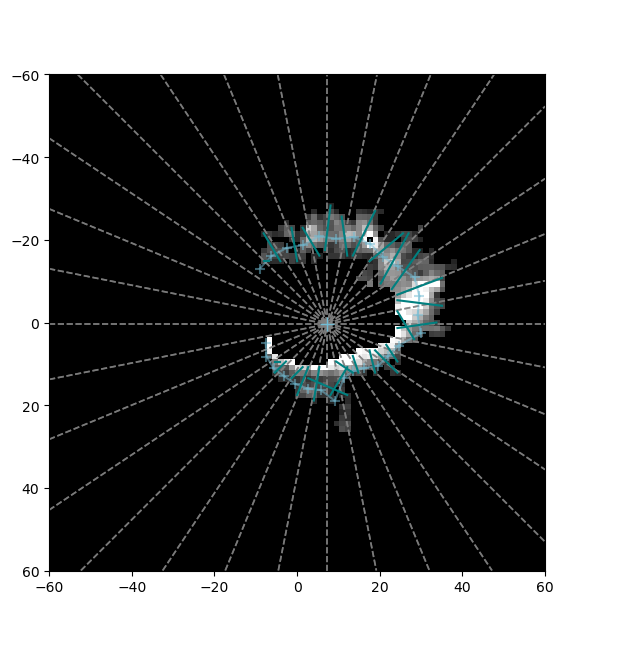

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No width.
9 Width: 5.559243540158641. Distance: 3.8451195956469615
10 Width: 6.875082490237463. Distance: 4.597820196783078
11 Width: 6.875082490237463. Distance: 6.963952586518657
12 Width: 13.881748504701573. Distance: 6.067005090954695
13 Width: 10.870459885346357. Distance: 5.787236972693503
14 Width: 6.875082490237463. Distance: 5.12062824712503
15 Width: 7.861957611027375. Distance: 6.022487989716379
16 Width: 7.260896369170119. Distance: 5.587069048715931
17 Width: 12.430846459271303. Distance: 5.63841795196821
18 Width: 6.029846231460097. Distance: 5.911231897315683
19 Width: 1.3483146067415666. Distance: 4.497587507047271
20. Invalid. No width.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation

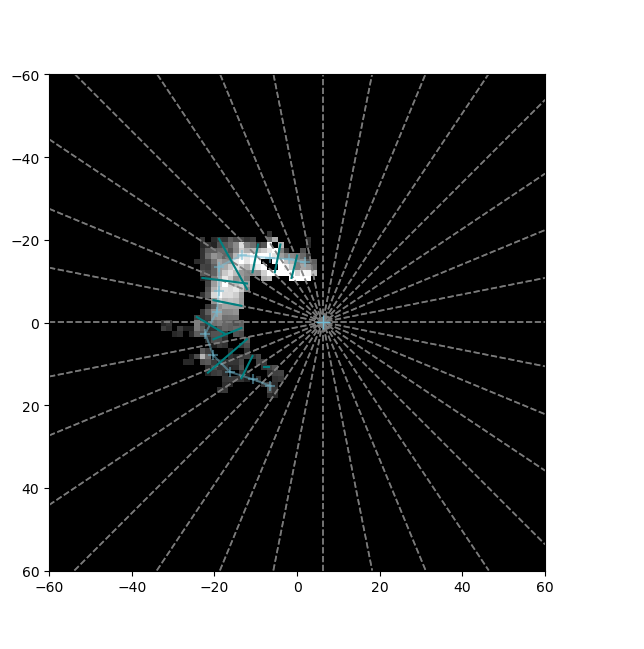

0 Width: 13.279358833882394. Distance: 5.836110671099793
1. Invalid. No width.
2. Invalid. No width.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No width.
13 Width: 3.0149231157300505. Distance: 6.722465139064032
14 Width: 1.9068048031996807. Distance: 5.125919944581278
15 Width: 10.870459885346357. Distance: 4.309426430671346
16 Width: 6.741573033707868. Distance: 5.136467658493479
17 Width: 3.014923115730053. Distance: 3.5346913953455252
18 Width: 3.0149231157300433. Distance: 3.7095870611305113
19 Width: 3.0149231157300567. Distance: 3.2857468986834353
20 Width: 1.3483146067415674. Distance: 2.974655990851566
21. Invalid. No width.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separation.
27.

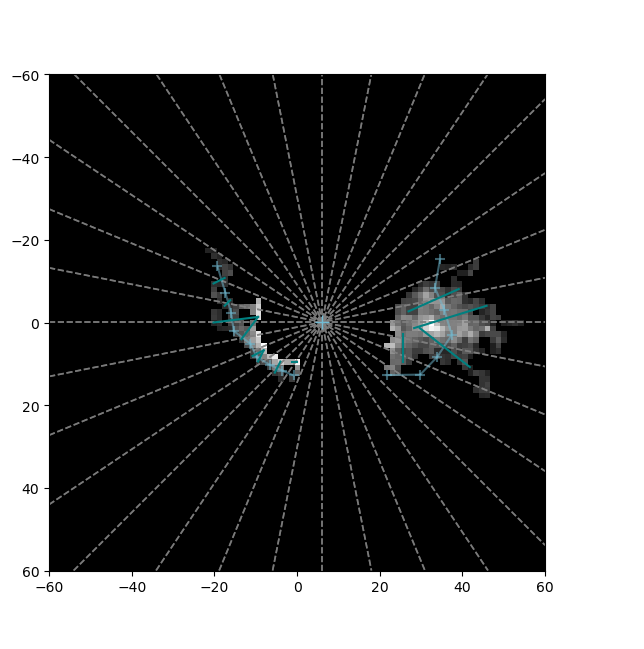

0 Width: 8.201477568941415. Distance: 3.9186141283746756
1 Width: 7.861957611027379. Distance: 4.136642238319629
2 Width: 9.534024015998398. Distance: 4.150093504249049
3 Width: 10.53067372032358. Distance: 3.9290330537083182
4 Width: 9.534024015998398. Distance: 4.3211847350537145
5 Width: 6.741573033707863. Distance: 3.4337033394405747
6 Width: 5.559243540158648. Distance: 3.498454471406257
7 Width: 11.598640809495684. Distance: 4.045814008623747
8 Width: 8.633425938111706. Distance: 4.355173878774958
9 Width: 8.20147756894142. Distance: 3.590356016687578
10 Width: 9.534024015998398. Distance: 4.445848026854983
11 Width: 11.598640809495679. Distance: 4.096258657958621
12 Width: 10.870459885346357. Distance: 6.532913285444575
13 Width: 14.332780871102898. Distance: 6.149386246993873
14 Width: 14.584252350191418. Distance: 6.287214026483318
15 Width: 9.72283490012761. Distance: 7.796645854174115
16 Width: 1.3483146067415666. Distance: 8.225166299840197
17. Invalid. No width.
18. Invali

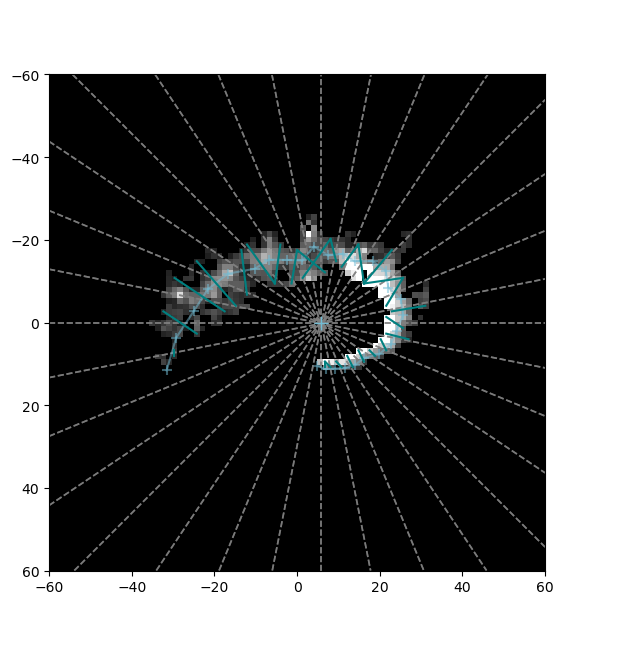

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No width.
14 Width: 9.534024015998398. Distance: 4.441119502665819
15 Width: 11.440828819198071. Distance: 6.754869541738442
16 Width: 4.861417450063802. Distance: 5.759992048589362
17. Invalid. No width.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No width.
21 Width: 1.3483146067415674. Distance: 6.530923416547998
22 Width: 4.861417450063805. Distance: 4.550923475877984
23 Width: 12.430846459271303. Distance: 5.0572253772000435
24 Width: 10.53067372032358. Distance: 4.404347409228245
25. Invalid. No width.
26 Width: 9.815878502400702. Distance: 3.7174829108164897
27 Width: 6.741573033707869. Distance

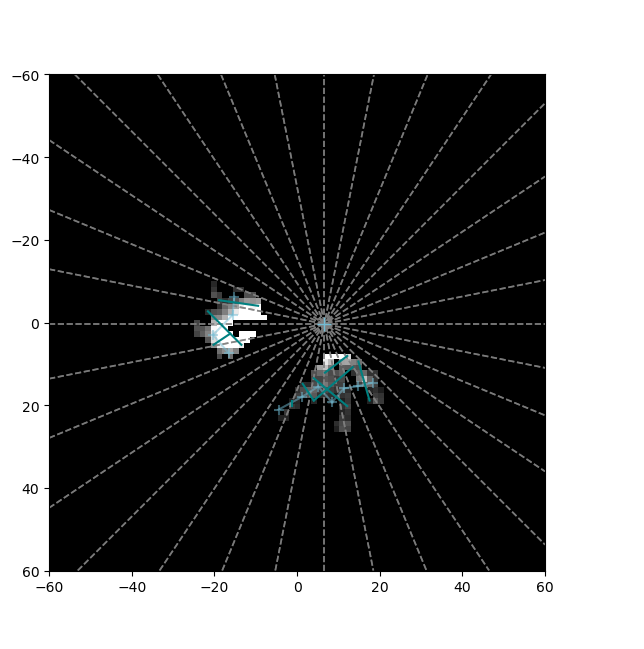

0 Width: 12.430846459271306. Distance: 6.745617867324285
1 Width: 14.332780871102901. Distance: 4.775293506056964
2 Width: 11.440828819198066. Distance: 4.155598966875814
3 Width: 16.458277234697125. Distance: 3.9106456873501654
4 Width: 6.029846231460108. Distance: 5.578328834104478
5. Invalid. No width.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No width.
14 Width: 0.0. Distance: 3.4059808756099508
15 Width: 3.813609606399356. Distance: 4.0703048233987085
16 Width: 5.720414409599038. Distance: 4.084463454007186
17 Width: 2.696629213483142. Distance: 4.509318456270995
18 Width: 6.029846231460107. Distance: 2.78532080434677
19 Width: 8.527490319555177. Distance: 3.0643504845302822
20 Width: 5.393258426966291. Distance: 5.345452064687212
21 Width: 12.209508051421244. Distance: 3.512148732668329
22 Width: 4.0449438202247165. Dis

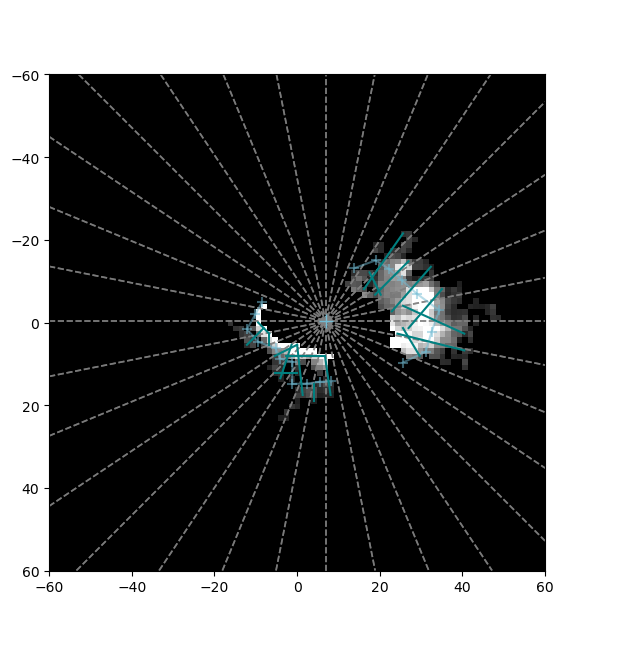

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No width.
6 Width: 4.263745159777591. Distance: 1.8853752095998304
7 Width: 6.029846231460107. Distance: 3.843659393702144
8 Width: 6.741573033707863. Distance: 4.847453263734596
9 Width: 13.550394095893337. Distance: 3.48160816557229
10 Width: 8.201477568941423. Distance: 3.980151135349123
11 Width: 8.201477568941423. Distance: 5.968358855725407
12 Width: 15.373151799089504. Distance: 6.427997593899413
13 Width: 13.881748504701571. Distance: 7.802701783138671
14 Width: 17.988760535900678. Distance: 6.405695332617218
15 Width: 8.089887640449444. Distance: 6.432513103541868
16 Width: 6.029846231460107. Distance: 9.541079704603112
17. Invalid. No width.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separatio

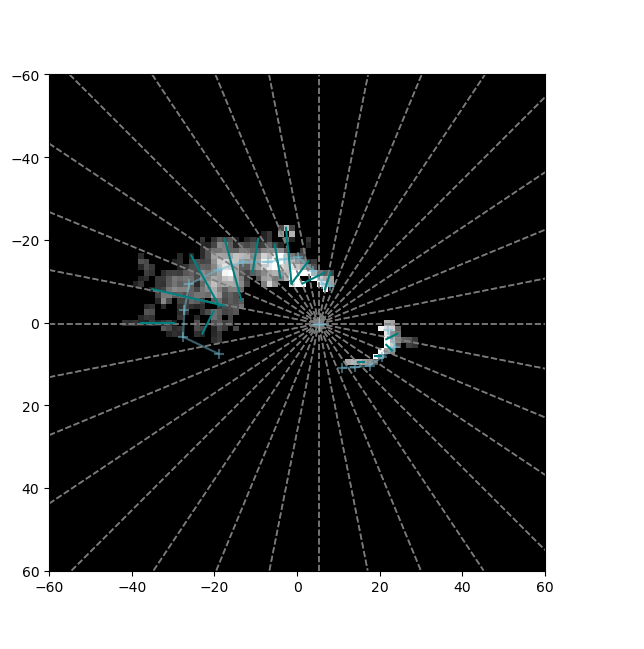

0 Width: 15.07461557865026. Distance: 6.000580232672214
1 Width: 8.20147756894143. Distance: 7.336881850171812
2. Invalid. No width.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No width.
15 Width: 4.263745159777589. Distance: 4.1179992027936425
16 Width: 1.3483146067415746. Distance: 4.032218365402732
17 Width: 0.0. Distance: 4.8237407329358835
18 Width: 0.0. Distance: 3.604351250553263
19. Invalid. No width.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separation.
27. Invalid. No separation.
28. Invalid. No width.
29. Invalid. No width.
30 Width: 11.520005049866334. Distance: 7.43419

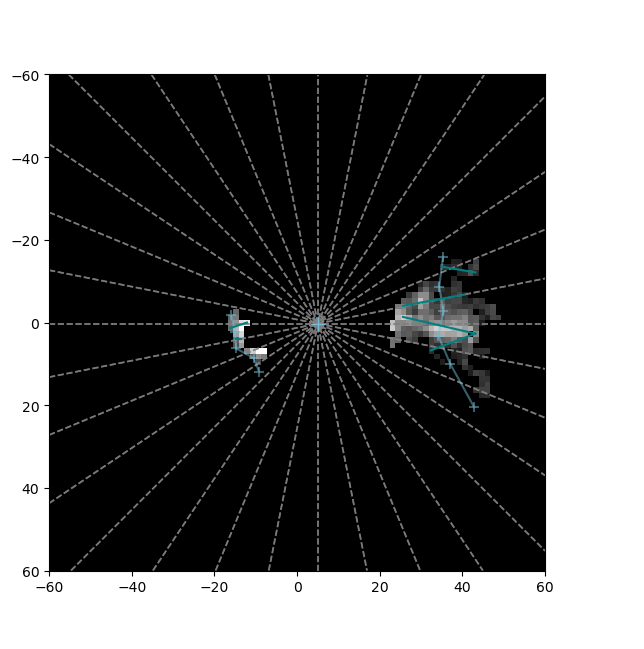

0 Width: 10.870459885346367. Distance: 4.443267153730217
1 Width: 9.722834900127618. Distance: 5.038165133430296
2 Width: 13.750164980474926. Distance: 4.287467554618744
3 Width: 9.815878502400702. Distance: 4.494417148332914
4 Width: 8.633425938111705. Distance: 6.9127432336114545
5 Width: 7.627219212798709. Distance: 2.7015550552577747
6 Width: 8.20147756894142. Distance: 2.674916928279838
7 Width: 8.52749031955518. Distance: 2.912655312605199
8 Width: 10.870459885346364. Distance: 2.8527733430530247
9 Width: 7.86195761102737. Distance: 2.8526960792975533
10 Width: 9.53402401599839. Distance: 3.87571876232927
11 Width: 10.530673720323577. Distance: 3.2764334686540963
12 Width: 7.26089636917012. Distance: 5.072266216438859
13 Width: 12.430846459271313. Distance: 4.308134456497601
14 Width: 10.87045988534636. Distance: 4.5715446454774
15 Width: 6.7415730337078665. Distance: 0
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.

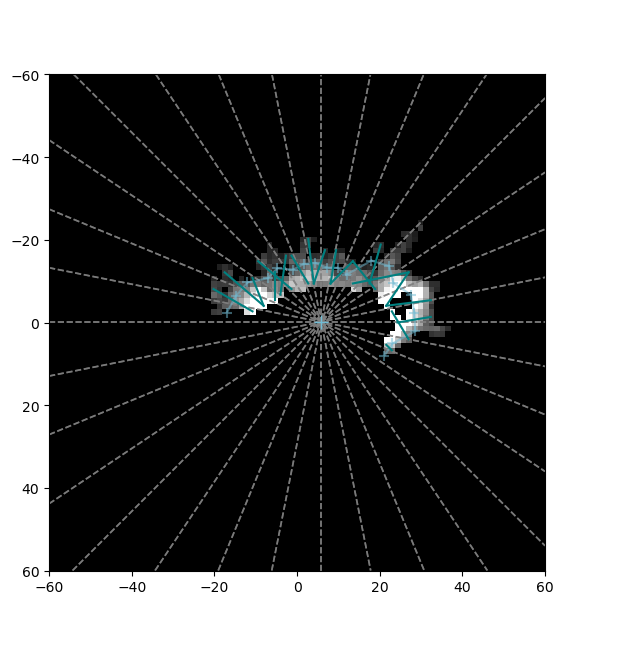

0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No width.
10 Width: 1.9068048031996807. Distance: 5.7033477145944875
11 Width: 8.527490319555175. Distance: 4.419416932262177
12 Width: 8.08988764044944. Distance: 6.4239362842792564
13 Width: 12.43084645927131. Distance: 5.652492329003871
14 Width: 16.23585785904579. Distance: 5.258114826261858
15 Width: 10.870459885346357. Distance: 5.533082341734072
16. Invalid. No width.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separation.
27. Invalid. No separation.
28. Invalid. No separation.
29. Invalid. No separation.
30.

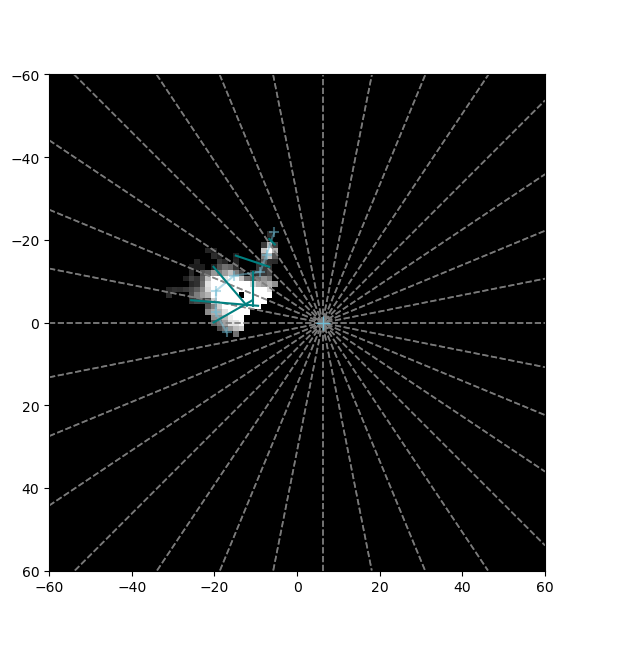

0 Width: 13.483146067415724. Distance: 6.398121637242515
1 Width: 11.520005049866336. Distance: 5.997187560055955
2 Width: 11.118487080317285. Distance: 5.543966439023811
3 Width: 3.0149231157300567. Distance: 6.405921864284176
4. Invalid. No width.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No width.
13 Width: 5.559243540158643. Distance: 5.831802823941
14. Invalid. No width.
15 Width: 8.527490319555184. Distance: 4.4053556653499735
16 Width: 6.029846231460107. Distance: 5.789861112002091
17 Width: 2.696629213483142. Distance: 4.310208790036462
18 Width: 1.3483146067415746. Distance: 3.227750094292473
19 Width: 0.0. Distance: 3.816542107798266
20. Invalid. No width.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separat

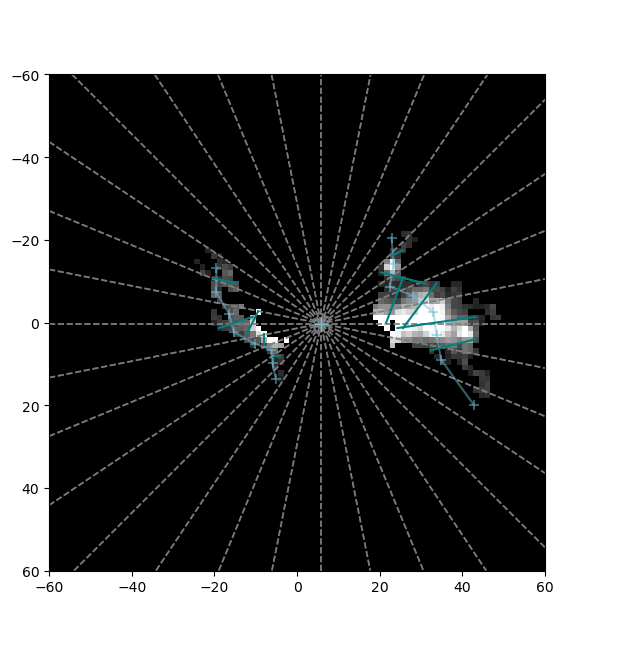

0 Width: 0.0. Distance: 4.31563631946143
1. Invalid. No width.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No width.
5 Width: 1.3483146067415746. Distance: 2.0455882092232525
6 Width: 1.9068048031996865. Distance: 1.98674311851293
7 Width: 5.720414409599038. Distance: 2.7230452275016055
8 Width: 6.741573033707867. Distance: 5.034614632047166
9 Width: 16.291747380127507. Distance: 4.076655326927889
10. Invalid. No width.
11 Width: 9.044769347190154. Distance: 3.5629119275276686
12 Width: 6.875082490237464. Distance: 6.193027666570234
13 Width: 15.373151799089502. Distance: 9.733956084710703
14 Width: 13.881748504701571. Distance: 6.6228362128092675
15 Width: 13.279358833882384. Distance: 7.59946280847861
16 Width: 0.0. Distance: 7.118853695051116
17. Invalid. No width.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25.

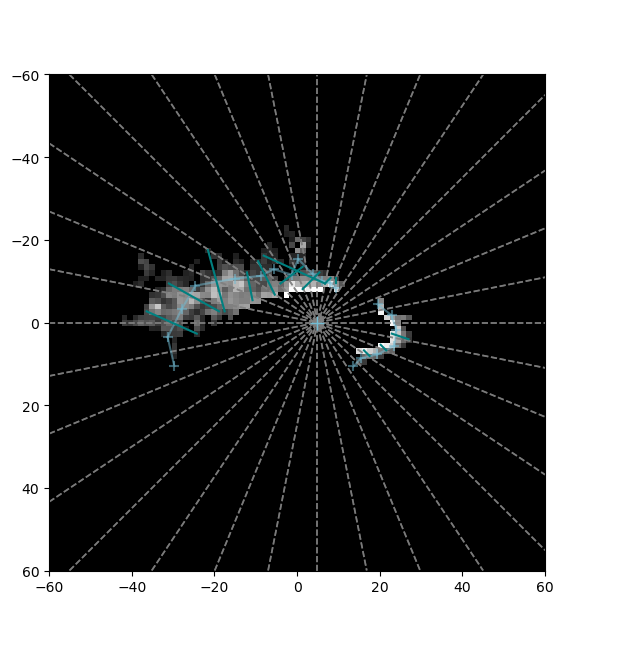

0 Width: 6.741573033707864. Distance: 6.6976233410853965
1 Width: 12.43084645927131. Distance: 5.346438002937022
2 Width: 8.527490319555177. Distance: 5.781988855295473
3 Width: 9.534024015998396. Distance: 4.8933589290741315
4 Width: 9.044769347190162. Distance: 5.992604696467227
5. Invalid. No width.
6. Invalid. No width.
7 Width: 7.260896369170119. Distance: 5.44536896497819
8 Width: 9.722834900127612. Distance: 3.097250521260498
9 Width: 5.559243540158643. Distance: 2.9060777342174315
10 Width: 0.0. Distance: 5.285211925945163
11 Width: 1.9068048031996752. Distance: 3.801323363446939
12 Width: 2.696629213483142. Distance: 4.764291120736012
13 Width: 4.861417450063811. Distance: 6.315371129148602
14 Width: 3.0149231157300505. Distance: 4.97758838673354
15 Width: 3.0149231157300567. Distance: 6.1554084353903855
16 Width: 3.0149231157300505. Distance: 4.555027523910942
17. Invalid. No width.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invali

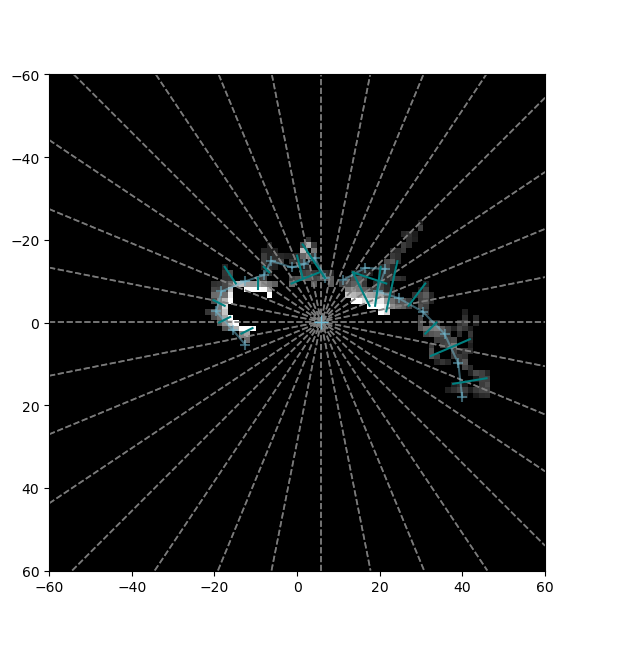

0 Width: 13.483146067415724. Distance: 7.015453888570107
1 Width: 11.118487080317285. Distance: 6.244999815206286
2 Width: 13.750164980474926. Distance: 6.129376265265716
3 Width: 12.430846459271306. Distance: 5.075991230809888
4. Invalid. No width.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No separation.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separation.
27. Invalid. No separation.
28. Invalid. No separation.
29. Invalid. No separation.
30 Width: 6.7415730337078665. Distance: 0
31 Width: 16.

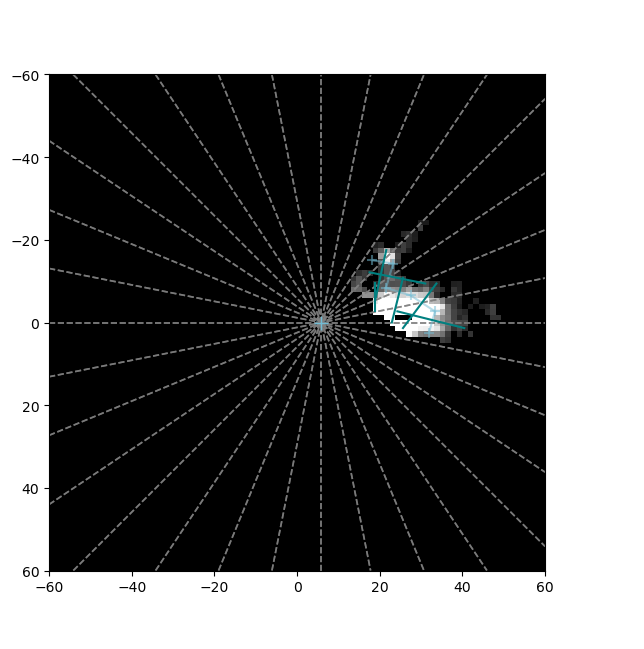

In [255]:
# define necessary values to be updated
ratio = 0
length_array = []
width_array = []
ratio_array = []
current_rotation = 0

for file in sorted(segmented_path.iterdir()):
    if file.is_file():

        numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', f'{file.name}')]
        angles = numbers[1:-1]
        d = angles[0]
        a = angles[1]
        
        # load the matched-filter detection output fits file
        hdul = fits.open(f'{mf_catalogs_path}/mf_{galaxy_name}_d={d}_a={a}_pix=8000.fits')
        image_data = np.squeeze(hdul[0].data)

        # extract the area_of_interest
        image_data[~area_of_interest[current_rotation, :, :]] = 0
        
        # access centers calculated by the 2D exponential fit algorithm
        x_center, y_center = centers(f'{file.name}', galaxy_name)
        
        # plot the bins (only for visual help)
        max_length = 89
        n_bins = 32  
        angles = np.linspace(0, 2 * np.pi, n_bins, endpoint=False)
        
        fig, ax = plt.subplots(figsize=(8, 8))
        
        for angle in angles:
            if np.isclose(angle, np.pi/2) or np.isclose(angle, 3*np.pi/2):
                ax.axvline(x=x_center, color='gray', linestyle='--', linewidth=1.2, alpha=0.8)
            else:
                slope = np.tan(angle)
                ax.axline(
                    (x_center, y_center), 
                    slope=slope, 
                    color='gray', 
                    linestyle='--', 
                    linewidth=1.2, 
                    alpha=0.8
                )
        
        ax.plot(x_center, y_center, color='#72BCD4', marker='+', markersize=10, label='Center')
        
        # identify outliers
        outliers = find_large_outliers(np.unique(image_data))
        outlier_mask = np.isin(image_data, outliers)
        image_data[outlier_mask] = 0
        
        # identify coordinates of interest
        x_of_interest = []
        y_of_interest = []
        val_of_interest = []
        
        for r_idx, row in enumerate(image_data):
            for c_idx, val in enumerate(row):
                if ~(val == 0):
                    val_of_interest.append(val)
                    # scale the data size (89x89) to the plot size (120x120) 
                    scaled_r = -60 + (r_idx * (120 / 89)) #- 120/178
                    scaled_c = -60 + (c_idx * (120 / 89)) #- 120/178
                    x_of_interest.append(scaled_c) # try switching columns and rows
                    y_of_interest.append(scaled_r)
        
        # number of pixels of interest
        n_of_interest = len(x_of_interest)
        
        # calculate the average readius of each bin
        avg_radii, bin_size = radius_calc(n_of_interest, n_bins, x_center, y_center, x_of_interest, y_of_interest)
        
        # plot points for the average radius at the angular midpoint of each bin
        angles = np.linspace(0, 2*np.pi, n_bins, endpoint=False)
        angles = (angles + bin_size / 2)
        
        x_ang = avg_radii * np.cos(angles) + x_center
        y_ang = -avg_radii * np.sin(angles) + y_center
        
        cmap = plt.cm.gray.copy() # brighter areas represent higher star density
        cmap.set_bad(color='black')
        
        # set value scale AFTER the center is removed
        min_obj = np.min(image_data)
        max_obj = np.max(image_data)
        
        plt.scatter(x_ang, y_ang, color='#72BCD4', marker='+', s=50, alpha=0.5)
        
        # calculate stream length
        total_dist = length_calc(n_bins, x_center, y_center, x_ang, y_ang)
        
        # calculate stream width
        stream_width_counter, stream_width_total = width_calc(image_data, n_bins, x_ang, y_ang)
        
        # calculate average stream width
        if stream_width_counter != 0:
            avg_width = stream_width_total/stream_width_counter
            ratio = total_dist/avg_width
        else:
            avg_width = np.nan
            ratio = np.nan
        print(f"Average Width: {avg_width}")
        print(f"Total Distance: {total_dist}")
        print(f"Length/Width Ratio: {ratio}")
        
        # plot the image with lengths and widths
        current_cmap = copy.copy(mpl.colormaps['gray'])
        current_cmap.set_bad(color='black')
        
        plt.imshow(image_data, extent=[-60,60,-60,60], cmap = current_cmap, vmin=0, vmax=10)
        
        length_array.append(total_dist)
        width_array.append(avg_width)
        ratio_array.append(ratio)
        
        cbar = plt.colorbar(orientation='vertical')
        if cbar.solids is not None:
            cbar.solids.set_alpha(0)
        if hasattr(cbar, 'lines') and isinstance(cbar.lines, list):
            for line in cbar.lines:
                line.set_alpha(0)
        cbar.outline.set_alpha(0)
        cbar.ax.tick_params(axis='both', colors=(0,0,0,0), labelcolor=(0,0,0,0))
        #cbar.set_label('Stellar Density Level', rotation=270, labelpad=15)
        
        plt.gca().xaxis.set_visible(True)
        plt.gca().yaxis.set_visible(True)
        
        ax.invert_yaxis()
        stfit_path = path(f'stfit_outputs/{galaxy_name}/fitted/stfit_{galaxy_name}_fitted_d={d}_a={a}_pix={numpix}.png')
        stfit_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(f'{stfit_path}', dpi=300, bbox_inches='tight', transparent=True)
        plt.show()
        hdul.close()
        
        current_rotation = current_rotation + 1

In [256]:
def fibonacci_angler(n):
    """ Calculates n equally-spaced angles around a sphere.

    Args:
        n (int):
            The desired number of angles.

    Returns:
        declination_array (array of floats):
            The declinations of the calculated angles.
        azimuthal_array (array of floats):
            The azimuthals of the calculated angles.
    """
    golden_ratio = (1 + np.sqrt(5))/2

    i_array = np.linspace(0,n-1,n)
    z_array = 1 - i_array/((n-1)) ###ONLY GOES HALF WAY DOWN
    radius_array = np.sqrt(1-z_array**2)

    declination_array = np.pi/2-np.arcsin(z_array)
    azimuthal_array = 2*np.pi * i_array/golden_ratio

    return declination_array, azimuthal_array

declination_array, azimuthal_array = fibonacci_angler(numangles)

In [257]:
def func_fit(theta, length, width):
    """ Ratio as a function of length and width, assuming that the stream is cylindrical.

    Args:
        theta ((array of) float(s)):
            Angle(s) of observation (either declination or azimuthal).
        length ((array of) float(s)):
            Length(s) of the stream.
        width ((array of) float(s)):
            Width(s) of the stream.

    Returns:
        ratio ((array of) float(s)):
            The length-to-width ratio(s) of the stream.
    """

    ratio = (length * np.cos(theta * np.pi / 180) + width * np.sin(theta * np.pi / 180)) / width
    
    return ratio

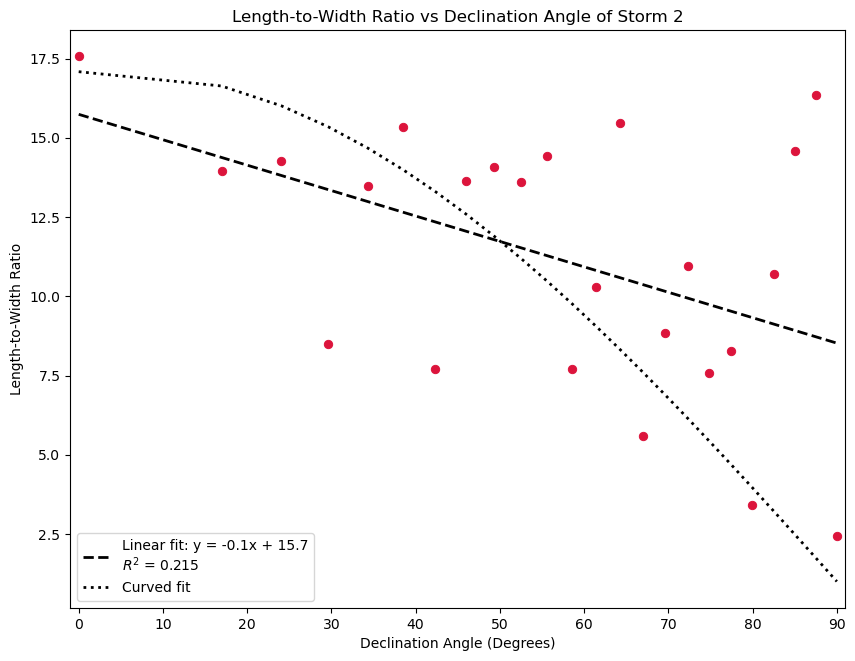

y= -0.08022935534256728 x + 15.742874125233621 , R^2= 0.21547333135147015


In [258]:
# plot and save the length-to-width ratio vs. declination graph with a linear and a curved fit

x = declination_array * 180 / (np.pi)
y = ratio_array

p0 = np.array([22,1])
popt, pcov = curve_fit(func_fit, x, y, p0)
our_plot = func_fit(x, popt[0], popt[1])

m, b = np.polyfit(x, y, deg=1)
y_pred = m * x + b

r_matrix = np.corrcoef(x, y)
r_value = r_matrix[0, 1]
r_squared = r_value ** 2

fig, ax = plt.subplots(figsize=(10, 7.5))

ax.scatter(x, y, color='crimson', linewidth=0.7)
ax.plot(x, y_pred, color='black', linestyle='--', linewidth=2, \
        label=f'Linear fit: y = {m:.1f}x + {b:.1f}\n$R^2$ = {r_squared:.3f}')
ax.plot(x, our_plot, color='black', linestyle=':', linewidth=2, \
        label=f'Curved fit')
ax.set_xlim(left=-1, right=91)

ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

ax.set_xlabel("Declination Angle (Degrees)")
ax.set_ylabel("Length-to-Width Ratio")
ax.set_title("Length-to-Width Ratio vs Declination Angle of Storm 2")

ax.legend()

ratio_v_angle_path=path(f'stfit_outputs/{galaxy_name}')
ratio_v_angle_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(f'{ratio_v_angle_path}/lw_vs_dec.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()
print('y=', m, 'x +', b, ', R^2=', r_squared)

In [259]:
# Define the path to save the length, width and their ratio for every angle
lw_path = path(f'stfit_outputs/{galaxy_name}/lw.txt')
lw_path.parent.mkdir(parents=True, exist_ok=True)

In [260]:
# Save the length, width and their ratio for every angle
if os.path.exists(lw_path):
    os.remove(lw_path)

for i in range(len(ratio_array)):
    with open(f'{lw_path}', 'a') as file:   
        file.write('center of ' f'{galaxy_name}' ' at d=' f'{x[i]:.1f}' ': length=' f'{length_array[i]}' ', width=' f'{width_array[i]}' ', length-to-width ratio=' f'{ratio_array[i]}' '\n')